# Лабораторная 6. Сегментация дорожных знаков

- Предобученные модели детекции, такие как Mask R-CNN детектируют и сегментируют объекты фиксированных классов, в том числе знаки “Стоп”<br>
- Предлагается обучить выбранную модель сегментировать 8 типов знаков на наборе данных Russian road signs https://www.kaggle.com/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset, содержащем 100000 изображений дорожных знаков России (набор для сегментации построен на основе набора данных для детекции https://graphics.cs.msu.ru/projects/traffic-sign-recognition.html)<br>
- Предобученные модели можно использовать из библиотеки MMDetection https://github.com/open-mmlab/mmdetection, а можно попробовать YOLO последней версии<br>
- Тестирование провести на 10 фотографиях улиц с дорожными знаками, сделанных самостоятельно на улице<br>
- Оценка качества сегментации производится с помощью метрик IoU, Precision, Recall, L2 отдельно на валидационной части набора изображений Russian road signs и сделанных фотографиях, также интересует процент изображений, на котором IoU >= 0.5, IoU >= 0.75, IoU >= 0.9<br>


In [26]:
import json
import glob
import os
import cv2
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint
from ultralytics import YOLO

## Распределение классов

In [9]:
def print_sign_categories_distribution(path):
    counter = {}
    for i in range(1, 3000):
        filename = f'{path}/{i}.jpg_coco.json'
        if not os.path.exists(filename):
            continue
        with open(filename, 'r', encoding='utf-8') as f:
            data = json.load(f)

        for class_id in data['class_ids']:
            if class_id not in counter:
                counter[class_id] = 0
            counter[class_id] += 1

    print(f'Sign categories distribution for {path}: {counter}')

print_sign_categories_distribution('dataset/train')
print_sign_categories_distribution('dataset/val')


Sign categories distribution for dataset/train: {3: 9933, 8: 1435, 1: 1378, 10: 597, 2: 19, 6: 111, 4: 14, 13: 2}
Sign categories distribution for dataset/val: {3: 531, 8: 86, 1: 84, 10: 28, 6: 9, 13: 1}


## Визуализация масок из COCO

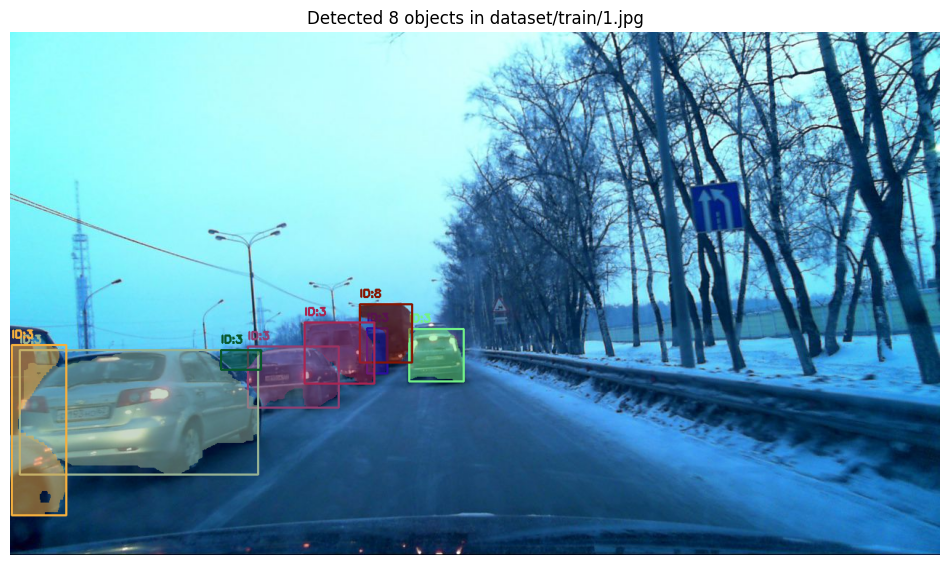

In [ ]:
def visualize_masks(image_path, json_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with open(json_path, 'r') as f:
        data = json.load(f)

    masks_raw = np.array(data['masks'])
    bboxes = data['bbox']
    class_ids = data['class_ids']

    overlay = img.copy()

    num_objects = len(class_ids)
    for i in range(num_objects):
        obj_mask_56 = masks_raw[:, :, i].astype(np.float32)

        y1, x1, y2, x2 = bboxes[i]
        bw, bh = x2 - x1, y2 - y1

        if bw <= 0 or bh <= 0: continue

        obj_mask_full = cv2.resize(obj_mask_56, (bw, bh), interpolation=cv2.INTER_LINEAR)
        binary_mask = obj_mask_full > 0.5

        color = np.random.randint(0, 255, (3,)).tolist()
        mask_region = overlay[y1:y2, x1:x2]

        for c in range(3):
            mask_region[:, :, c] = np.where(binary_mask,
                                          mask_region[:, :, c] * 0.5 + color[c] * 0.5,
                                          mask_region[:, :, c])

        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
        cv2.putText(overlay, f"ID:{class_ids[i]}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(overlay)
    plt.axis('off')
    plt.title(f"Detected {num_objects} objects in {image_path}")
    plt.show()

visualize_masks('dataset/train/1.jpg', 'dataset/train/1.jpg_coco.json')

## Визуализация VIA

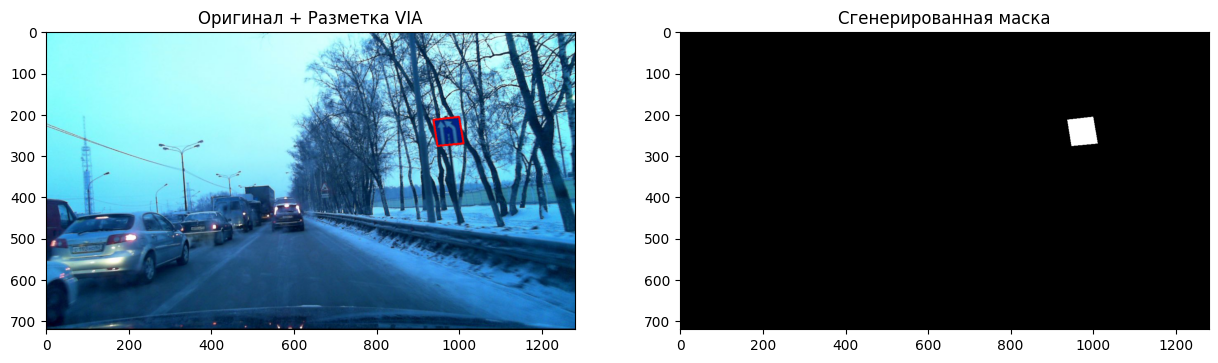

In [ ]:
def visualize_via_polygons(image_path, via_data_segment):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    regions = via_data_segment['regions']

    for r_id in regions:
        shape = regions[r_id]['shape_attributes']
        if shape['name'] == 'polygon':
            points = np.array(list(zip(shape['all_points_x'], shape['all_points_y'])))

            cv2.fillPoly(mask, [points], 255)

            cv2.polylines(img, [points], isClosed=True, color=(255, 0, 0), thickness=3)

    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.title("Оригинал + Разметка VIA")
    plt.imshow(img)
    plt.subplot(1, 2, 2)
    plt.title("Сгенерированная маска")
    plt.imshow(mask, cmap='gray')
    plt.show()


sample_via = {
    "regions": {
        "0": {
            "shape_attributes": {
                "name": "polygon",
                "all_points_x": [
                    937,
                    999,
                    1010,
                    947,
                    937
                ],
                "all_points_y": [
                    214,
                    207,
                    271,
                    277,
                    214
                ]
            }
        }
    }
}

visualize_via_polygons('./dataset/train/1.jpg', sample_via)

## Конвертация из VIA в YOLO

In [ ]:
def convert_via_to_yolo_all_shapes(json_path, output_labels_dir, img_dir):
    os.makedirs(output_labels_dir, exist_ok=True)
    with open(json_path, 'r', encoding='utf-8') as f:
        via_data = json.load(f)

    for data in via_data.values():
        filename = data['filename']
        img_w = data.get('file_attributes', {}).get('width', 1280)
        img_h = data.get('file_attributes', {}).get('height', 720)

        yolo_lines = []
        for region in data.get('regions', {}).values():
            shape = region['shape_attributes']
            class_id = 0
            points = []

            if shape['name'] == 'rect':
                x, y, w, h = shape['x'], shape['y'], shape['width'], shape['height']
                points = [(x, y), (x + w, y), (x + w, y + h), (x, y + h)]

            elif shape['name'] == 'circle':
                cx, cy, r = shape['cx'], shape['cy'], shape['r']
                for i in range(32):
                    angle = 2 * math.pi * i / 32
                    points.append((cx + r * math.cos(angle), cy + r * math.sin(angle)))

            elif shape['name'] == 'ellipse':
                cx, cy, rx, ry = shape['cx'], shape['cy'], shape['rx'], shape['ry']
                theta = shape.get('theta', 0)
                for i in range(32):
                    angle = 2 * math.pi * i / 32
                    dx = rx * math.cos(angle)
                    dy = ry * math.sin(angle)
                    tx = cx + dx * math.cos(theta) - dy * math.sin(theta)
                    ty = cy + dx * math.sin(theta) + dy * math.cos(theta)
                    points.append((tx, ty))

            elif shape['name'] == 'polygon':
                points = zip(shape['all_points_x'], shape['all_points_y'])

            if points:
                res = [f"{px/img_w:.6f} {py/img_h:.6f}" for px, py in points]
                yolo_lines.append(f"{class_id} {' '.join(res)}")

        label_path = os.path.join(output_labels_dir, os.path.splitext(filename)[0] + '.txt')
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))

convert_via_to_yolo_all_shapes('dataset/val/via_region_data.json', 'dataset/val/labels', 'dataset/val/images')
convert_via_to_yolo_all_shapes('dataset/train/via_region_data.json', 'dataset/train/labels', 'dataset/train/images')

## Проверка

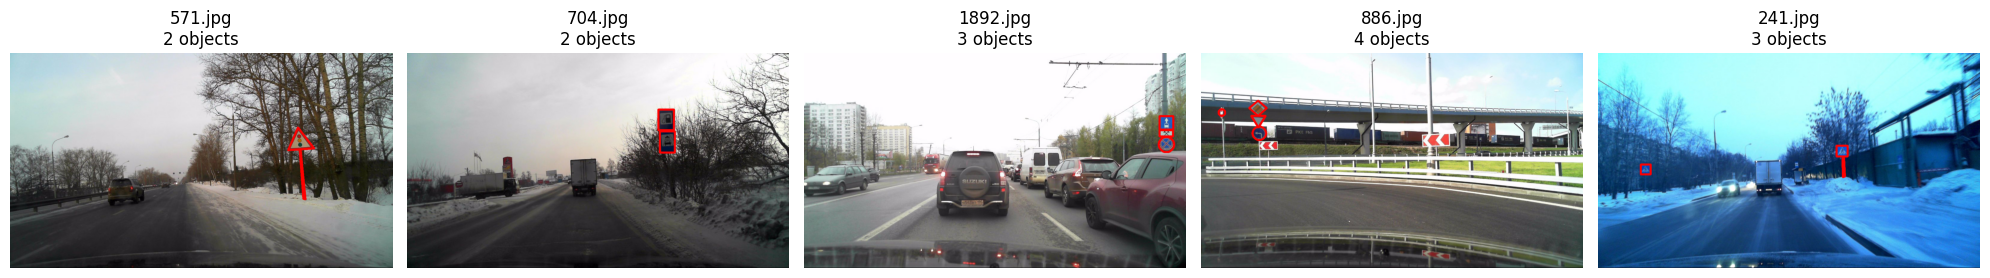

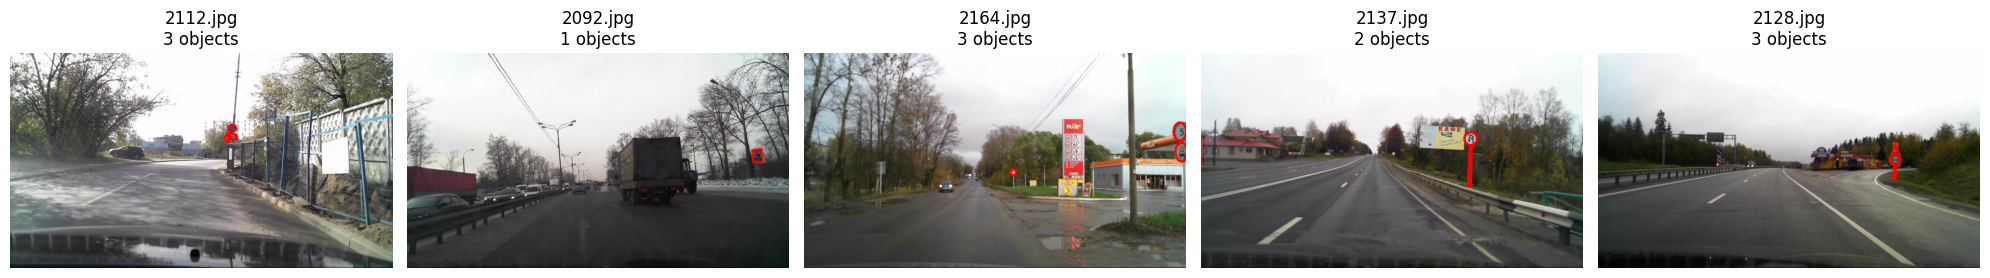

In [ ]:
def visualize_yolo_polygons(img_dir, label_dir, num_samples=5):
    all_labels = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    samples = random.sample(all_labels, min(num_samples, len(all_labels)))

    plt.figure(figsize=(20, 10))

    for i, label_name in enumerate(samples):
        img_name = label_name.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        label_path = os.path.join(label_dir, label_name)
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = list(map(float, line.strip().split()))
            coords = parts[1:]

            points = []
            for j in range(0, len(coords), 2):
                px = int(coords[j] * w)
                py = int(coords[j+1] * h)
                points.append([px, py])

            pts = np.array(points, np.int32).reshape((-1, 1, 2))
            cv2.polylines(img, [pts], isClosed=True, color=(255, 0, 0), thickness=5)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"{img_name}\n{len(lines)} objects")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


visualize_yolo_polygons('dataset/train/images', 'dataset/train/labels')
visualize_yolo_polygons('dataset/val/images', 'dataset/val/labels')

## Обучение

In [ ]:
model = YOLO('yolo11n-seg.pt')

results = model.train(
    data='data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device='cuda'
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

![img](./photos/res/seg.png)

## Тестирование на фотографиях улиц

In [ ]:
model = YOLO('seg_best.pt')

source = 'photos/'
results = model.predict(
    source=source,
    save=False,
    line_width=3,
    conf=0.3,
    verbose=False,
    imgsz=640
)

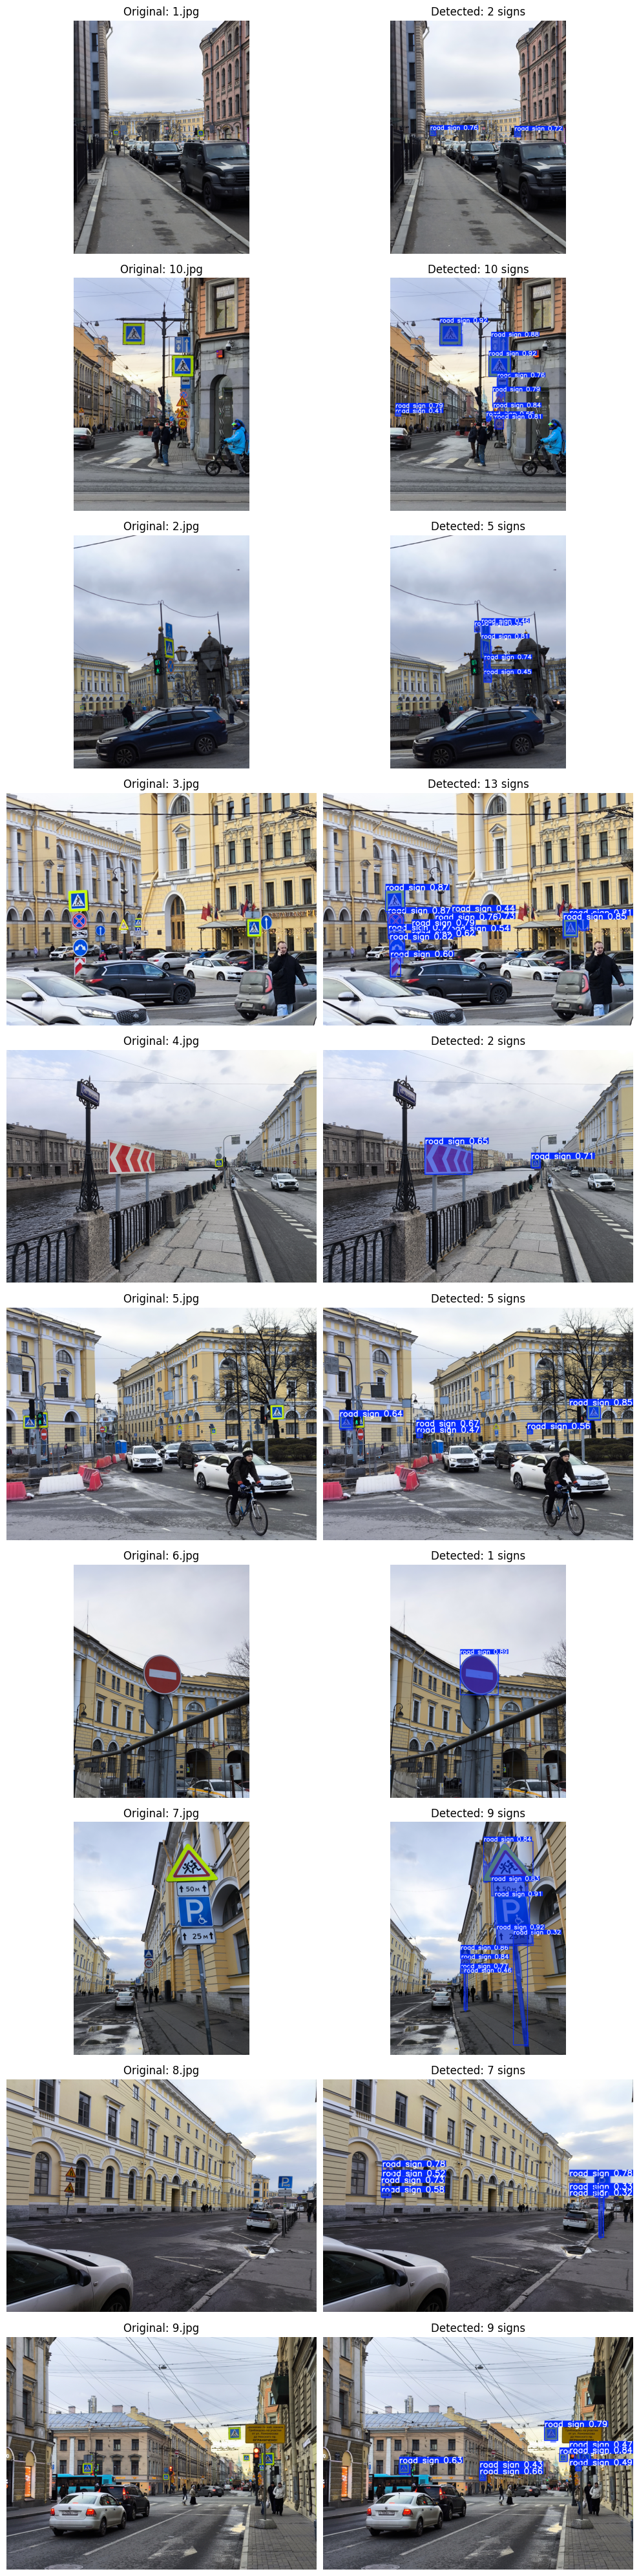

In [ ]:
fig, axes = plt.subplots(len(results), 2, figsize=(10, 4 * len(results)))

if len(results) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, r in enumerate(results):
    orig_img = cv2.cvtColor(r.orig_img, cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(orig_img)
    axes[i, 0].set_title(f"Original: {os.path.basename(r.path)}")
    axes[i, 0].axis('off')

    plotted_img = r.plot()
    rgb_result = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)
    axes[i, 1].imshow(rgb_result)
    axes[i, 1].set_title(f"Detected: {len(r.boxes)} signs")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Оценка качества

In [39]:
metrics = model.val(data='data.yaml')

print(f"Precision: {metrics.seg.p.mean():.4f}")
print(f"Recall: {metrics.seg.r.mean():.4f}")
print(f"mAP@50 (IoU 0.5): {metrics.seg.map50:.4f}")
print(f"mAP@50-95: {metrics.seg.map:.4f}")

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1193.8±364.5 MB/s, size: 102.6 KB)
val: Scanning /content/dataset/val/labels.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 18.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.0s
                   all        127        400      0.902      0.805      0.902      0.636       0.87      0.773      0.853      0.438
Speed: 4.3ms preprocess, 6.1ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/segment/val2
Precision: 0.8705
Recall: 0.7728
mAP@50 (IoU 0.5): 0.8534
mAP@50-95: 0.4380


In [ ]:
mp = metrics.seg.mp.mean() * 100
mr = metrics.seg.mr.mean() * 100
map50 = metrics.seg.map50 * 100
map75 = metrics.seg.map75 * 100

map90 = metrics.seg.all_ap[:, 8].mean() * 100

print(f"--- Результаты валидации (Masks) ---")
print(f"Precision (P):       {mp:.2f} %")
print(f"Recall (R):          {mr:.2f} %")
print(f"IoU >= 0.50 (mAP50): {map50:.2f} %")
print(f"IoU >= 0.75 (mAP75): {map75:.2f} %")
print(f"IoU >= 0.90 (mAP90): {map90:.2f} %")

--- Результаты валидации (Masks) ---
Precision (P):       87.05 %
Recall (R):          77.28 %
IoU >= 0.50 (mAP50): 85.34 %
IoU >= 0.75 (mAP75): 39.70 %
IoU >= 0.90 (mAP90): 9.03 %


In [ ]:
def calculate_l2_error(model, img_dir, label_dir):
    model = YOLO(model)
    results = model.predict(img_dir, conf=0.25, verbose=False, save=False)

    l2_distances = []

    for res in results:
        img_h, img_w = res.orig_shape
        if len(res.boxes) == 0: continue

        pred_centers = res.boxes.xywh[:, :2].cpu().numpy()

        label_path = os.path.join(label_dir, os.path.splitext(os.path.basename(res.path))[0] + '.txt')
        if not os.path.exists(label_path): continue

        with open(label_path, 'r') as f:
            gt_lines = [line.split() for line in f.readlines()]
            gt_centers = np.array([[float(l[1]) * img_w, float(l[2]) * img_h] for l in gt_lines])

        for pc in pred_centers:
            distances = np.linalg.norm(gt_centers - pc, ord=2, axis=1)
            l2_distances.append(np.min(distances))

    mean_l2 = np.mean(l2_distances)
    print(f"Средняя L2 ошибка (отклонение центра): {mean_l2:.2f} пикселей")
    return mean_l2


calculate_l2_error('runs/segment/train3/weights/best.pt', 'dataset/val/images', 'dataset/val/labels')

Средняя L2 ошибка (отклонение центра): 84.13 пикселей


np.float64(84.12887138426211)